In [1]:
# Instalación de las librerías necesarias
!pip install comet-ml transformers torch sacrebleu
!pip install git+https://github.com/Unbabel/COMET.git
!pip install pillow==9.5.0



  Cloning https://github.com/Unbabel/COMET.git to c:\users\carlos.basallote\appdata\local\temp\pip-req-build-i4ucake9
  Resolved https://github.com/Unbabel/COMET.git to commit e531fa805db59186f7ab0aa613c403a572b7ad06
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/Unbabel/COMET.git 'C:\Users\carlos.basallote\AppData\Local\Temp\pip-req-build-i4ucake9'


In [8]:
# (Opcional) Instalar dependencias en entornos limpios (por ejemplo, Google Colab)
# Descomenta si lo necesitas.
# !pip install -q "unbabel-comet>=2.2.0,<3.0" "pytorch-lightning<3.0" pillow==9.5.0 pandas numpy matplotlib

import os, re, sys, json
import pandas as pd
import numpy as np
import torch
from comet import download_model, load_from_checkpoint

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)


Dispositivo: cuda


In [9]:
# MODOS:
#   - "two_files": dos ficheros .srt (ES -> EN)
#   - "bilingual_single": un .srt bilingüe (primera línea ES, última línea EN por bloque)
MODE = "two_files"  # "two_files" o "bilingual_single"

# Rutas (edita según tu caso)
SRC_SRT = "sub_es.srt"    # Español (origen)
MT_SRT  = "sub_en.srt"    # Inglés (traducción automática)
REF_SRT = None                               # Ruta a referencia humana en inglés (opcional)

BILINGUAL_SRT = r"C:\ruta\subtitulos_bilingue.srt"  # si MODE == "bilingual_single"

# Ejecución
USE_GPU = 1 if device == "cuda" else 0
BATCH_SIZE = 16
CSV_OUT = "comet_scores.csv"


In [10]:
_time_re = re.compile(r"^\s*\d{2}:\d{2}:\d{2},\d{3}\s*-->\s*\d{2}:\d{2}:\d{2},\d{3}\s*$")

def parse_srt(path, strip_tags=True, drop_sdh=True):
    """Devuelve lista de dicts: [{'idx', 'start', 'end', 'text'}]."""
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        txt = f.read()
    txt = txt.replace("\r\n", "\n").replace("\r", "\n").strip()
    blocks = [b.strip() for b in re.split(r"\n\s*\n", txt) if b.strip()]
    out = []
    for b in blocks:
        lines = b.split("\n")
        idx = None
        start, end = None, None
        p = 0
        if lines and lines[0].strip().isdigit():
            idx = int(lines[0].strip())
            p = 1
        if p < len(lines) and _time_re.match(lines[p].strip()):
            times = lines[p].split("-->")
            start = times[0].strip()
            end = times[1].strip()
            p += 1
        text = "\n".join(lines[p:]).strip()
        if strip_tags:
            text = re.sub(r"<[^>]+>", "", text)
        if drop_sdh:
            text = re.sub(r"\[[^\]]*\]", "", text)
            text = re.sub(r"\([^)]*\)", "", text)
            text = re.sub(r"[♪]+", "", text)
        text = re.sub(r"\s+", " ", text).strip()
        out.append({"idx": idx, "start": start, "end": end, "text": text})
    return out

def align_two_srts(src_blocks, mt_blocks):
    n = min(len(src_blocks), len(mt_blocks))
    if len(src_blocks) != len(mt_blocks):
        print(f"[AVISO] Longitudes distintas: src={len(src_blocks)} vs mt={len(mt_blocks)}. Se recorta a {n}.")
    return src_blocks[:n], mt_blocks[:n]

def build_data_two_files(src_path, mt_path, ref_path=None):
    src_blocks = parse_srt(src_path)
    mt_blocks  = parse_srt(mt_path)
    src_blocks, mt_blocks = align_two_srts(src_blocks, mt_blocks)
    data = [{"src": s["text"], "mt": m["text"]} for s, m in zip(src_blocks, mt_blocks)]
    ref_blocks = None
    if ref_path:
        ref_blocks = parse_srt(ref_path)
        n = min(len(data), len(ref_blocks))
        if len(ref_blocks) != len(data):
            print(f"[AVISO] Referencia y datos difieren en longitud. Se recorta a {n}.")
        data = data[:n]
        for i in range(n):
            data[i]["ref"] = ref_blocks[i]["text"]
    meta = {
        "timestamps": [(s["start"], s["end"]) for s in src_blocks[:len(data)]],
        "src_texts": [s["text"] for s in src_blocks[:len(data)]],
        "mt_texts": [m["text"] for m in mt_blocks[:len(data)]],
        "ref_texts": [ref_blocks[i]["text"] for i in range(len(data))] if ref_path else None,
    }
    return data, meta

def build_data_bilingual_single(bi_path):
    blocks = parse_srt(bi_path, strip_tags=True, drop_sdh=True)
    data, timestamps, src_texts, mt_texts = [], [], [], []
    for b in blocks:
        parts = [p.strip() for p in re.split(r"[\n]+", b["text"]) if p.strip()]
        if len(parts) < 2:
            continue
        src = parts[0]
        mt  = parts[-1]
        data.append({"src": src, "mt": mt})
        timestamps.append((b["start"], b["end"]))
        src_texts.append(src)
        mt_texts.append(mt)
    meta = {"timestamps": timestamps, "src_texts": src_texts, "mt_texts": mt_texts, "ref_texts": None}
    return data, meta


In [11]:
if MODE == "two_files":
    data, meta = build_data_two_files(SRC_SRT, MT_SRT, REF_SRT)
elif MODE == "bilingual_single":
    data, meta = build_data_bilingual_single(BILINGUAL_SRT)
else:
    raise ValueError("MODE debe ser 'two_files' o 'bilingual_single'.")
print(f"Segmentos listos para COMET: {len(data)}")
print("Ejemplo:", data[0] if data else None)


Segmentos listos para COMET: 296
Ejemplo: {'src': '¡Gracias!', 'mt': 'Thank you!'}


In [14]:
# has_ref = any(("ref" in d) for d in data)
# model_name = "wmt21-comet-da" if has_ref else "wmt21-comet-qe-da"
# print("Usando modelo:", model_name)

# model_path = download_model(model_name)
# comet_model = load_from_checkpoint(model_path)
# res = comet_model.predict(data, batch_size=BATCH_SIZE, gpus=USE_GPU)
# print("Claves devueltas por COMET:", list(res.keys()))

# seg_scores = res.get("scores") or res.get("segment_scores") or res.get("segments_scores")
# sys_score  = res.get("system_score") or res.get("score")
# print("Puntuación global (system):", sys_score)
# print("Primeros 5 segmentos:", seg_scores[:5] if seg_scores else None)
has_ref = any(("ref" in d) for d in data)
model_name = "wmt21-comet-da" if has_ref else "wmt21-comet-qe-da"
print("Usando modelo:", model_name)

model_path = download_model(model_name)
comet_model = load_from_checkpoint(model_path)
res = comet_model.predict(data, batch_size=BATCH_SIZE, gpus=USE_GPU)
print("Claves devueltas por COMET:", list(res.keys()))

seg_scores = res.get("scores") or res.get("segment_scores") or res.get("segments_scores")
sys_score  = res.get("system_score") or res.get("score")
print("Puntuación global (system):", sys_score)
print("Primeros 5 segmentos:", seg_scores[:5] if seg_scores else None)

# --- Escalado mínimo a [0,1] (asumiendo rango ≈ [-1, 1]) ---
import numpy as np

def to01(x):
    x = np.asarray(x, dtype=float)
    return (x + 1.0) / 2.0

seg_scores_01 = to01(seg_scores) if seg_scores is not None else None
sys_score_01  = float(to01([sys_score])[0]) if sys_score is not None else None

print("Puntuación global (system) [0-1]:", sys_score_01)
print("Primeros 5 segmentos [0-1]:", seg_scores_01[:5] if seg_scores_01 is not None else None)

# (opcional) Guardar en el dict de salida por si lo quieres reutilizar
res["scores_01"] = seg_scores_01
res["system_score_01"] = sys_score_01


Usando modelo: wmt21-comet-qe-da


wmt21-comet-qe-da is already in cache.
Lightning automatically upgraded your loaded checkpoint from v1.3.5 to v2.5.2. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\carlos.basallote\.cache\torch\unbabel_comet\wmt21-comet-qe-da\checkpoints\model.ckpt`
Encoder model frozen.
C:\Users\carlos.basallote\AppData\Roaming\Python\Python311\site-packages\pytorch_lightning\core\saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 19/19 [00:01<00:00, 13.00i

Claves devueltas por COMET: ['scores', 'system_score']
Puntuación global (system): -0.005543229981904497
Primeros 5 segmentos: [0.23549650609493256, -0.05206896737217903, -0.0897635668516159, -0.004193859174847603, 0.15977337956428528]
Puntuación global (system) [0-1]: 0.49722838500904776
Primeros 5 segmentos [0-1]: [0.61774825 0.47396552 0.45511822 0.49790307 0.57988669]


,segment,start,end,src,mt,ref,comet_score
0,1,"00:00:03,656","00:00:05,656",¡Gracias!,Thank you!,None,0.617748
1,2,"00:00:28,104","00:00:30,864",Me viene Pilar que a ver si le puedo llevar en...,I have Pilar coming to see if I can take him i...,None,0.473966
2,3,"00:00:31,544","00:00:33,464",Una faena. Me habían quitado todos los puntos.,I had all my stitches removed.,None,0.455118
3,4,"00:00:34,344","00:00:35,484","Nada, no se tarda nada.","Nothing, it won't take a minute.",None,0.497903
4,5,"00:00:36,360","00:00:37,560",Un momentito.,Just a moment.,None,0.579887



Resumen COMET por segmento [0-1]:
count    296.000000
mean       0.497228
std        0.052815
min        0.345246
5%         0.410491
10%        0.424223
25%        0.461978
50%        0.497608
75%        0.538124
90%        0.563168
95%        0.580388
max        0.617748
Name: comet_score, dtype: float64

PEORES segmentos:


,segment,start,end,comet_score,src,mt
15,16,"00:01:02,920","00:01:04,960",0.345246,"Bueno, pues nada más salir un atasco.","Well, it's just a jam."
244,245,"00:11:45,528","00:11:46,568",0.357986,Si no le doy vueltas.,If I don't spin it.
50,51,"00:02:52,252","00:02:53,992",0.364134,Yo pinchaba y el Pepe lo ponía a copa.,I'd prick and Pepe'd put it in a drink.
206,207,"00:10:13,768","00:10:15,188",0.378138,Me da apuro mandarla a tomar por saco,I'm in a hurry to take her for a sack.
81,82,"00:03:59,896","00:04:02,816",0.380754,"La gente le dio por ahí, me hinché a vender fu...","People gave him around, I swelled up to sell f..."



MEJORES segmentos:


,segment,start,end,comet_score,src,mt
0,1,"00:00:03,656","00:00:05,656",0.617748,¡Gracias!,Thank you!
192,193,"00:09:43,304","00:09:45,004",0.607162,"Fue maravilloso, muchas gracias, ¿eh?","It was wonderful, thanks a lot, huh?"
113,114,"00:05:39,744","00:05:40,744",0.599875,Carillana de la Cruz.,Carillana de la Cruz.
273,274,"00:13:01,656","00:13:02,976",0.599832,Para mí el respeto es lo primero.,"For me, respect comes first."
10,11,"00:00:52,360","00:00:53,360",0.599252,¿Qué es eso?,What's that?


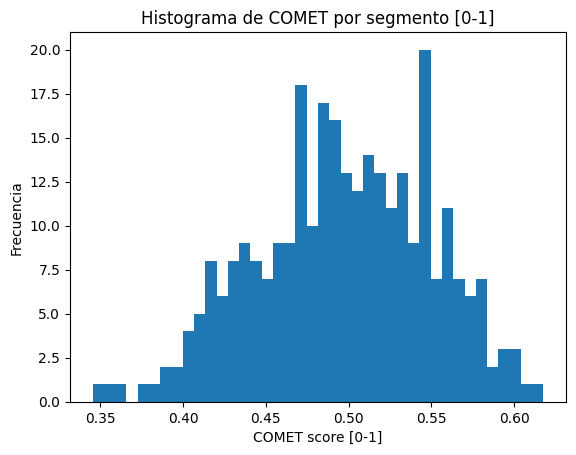


CSV guardado en: c:\Users\carlos.basallote\Desktop\comet_scores.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np  # añadido para la conversión a [0,1]

def to01(x):
    x = np.asarray(x, dtype=float)
    return (x + 1.0) / 2.0

rows = []
for i, s in enumerate(seg_scores, start=1):
    row = {
        "segment": i,
        "start": meta["timestamps"][i-1][0] if meta["timestamps"] else None,
        "end":   meta["timestamps"][i-1][1] if meta["timestamps"] else None,
        "src":   meta["src_texts"][i-1] if meta["src_texts"] else None,
        "mt":    meta["mt_texts"][i-1] if meta["mt_texts"] else None,
        "ref":   meta["ref_texts"][i-1] if meta.get("ref_texts") else None,
        "comet_score": s,  # se construye con el raw...
    }
    rows.append(row)

df = pd.DataFrame(rows)

# --- único cambio: reescalo y sobrescribo la columna ---
df["comet_score"] = to01(df["comet_score"])  # ahora comet_score ∈ [0,1]

display(df.head())

print("\nResumen COMET por segmento [0-1]:")
print(df["comet_score"].describe(percentiles=[.05,.10,.25,.5,.75,.90,.95]))

N = 5
print("\nPEORES segmentos:")
display(df.nsmallest(N, "comet_score")[ ["segment","start","end","comet_score","src","mt"] ])

print("\nMEJORES segmentos:")
display(df.nlargest(N, "comet_score")[ ["segment","start","end","comet_score","src","mt"] ])

plt.figure()
plt.hist(df["comet_score"].dropna(), bins=40)
plt.title("Histograma de COMET por segmento [0-1]")
plt.xlabel("COMET score [0-1]")
plt.ylabel("Frecuencia")
plt.show()


In [23]:
plt.show()
